<a href="https://colab.research.google.com/github/Khushibung05/RNN/blob/main/RNN3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Using Colab cache for faster access to the 'sentiment-analysis-for-mental-health' dataset.
Path to dataset files: /kaggle/input/sentiment-analysis-for-mental-health
['Combined Data.csv']

FIRST 5 ROWS:

   Unnamed: 0                                          statement   status
0           0                                         oh my gosh  Anxiety
1           1  trouble sleeping, confused mind, restless hear...  Anxiety
2           2  All wrong, back off dear, forward doubt. Stay ...  Anxiety
3           3  I've shifted my focus to something else but I'...  Anxiety
4           4  I'm restless and restless, it's been a month n...  Anxiety

DATASET SHAPE:
(53043, 3)

COLUMN NAMES:
Index(['Unnamed: 0', 'statement', 'status'], dtype='object')

UNIQUE SENTIMENT CLASSES:

['Anxiety' 'Normal' 'Depression' 'Suicidal' 'Stress' 'Bipolar'
 'Personality disorder']

NUMBER OF CLASSES:
7

CLASS DISTRIBUTION:

status
Normal                  16351
Depression              15404
Suicidal               

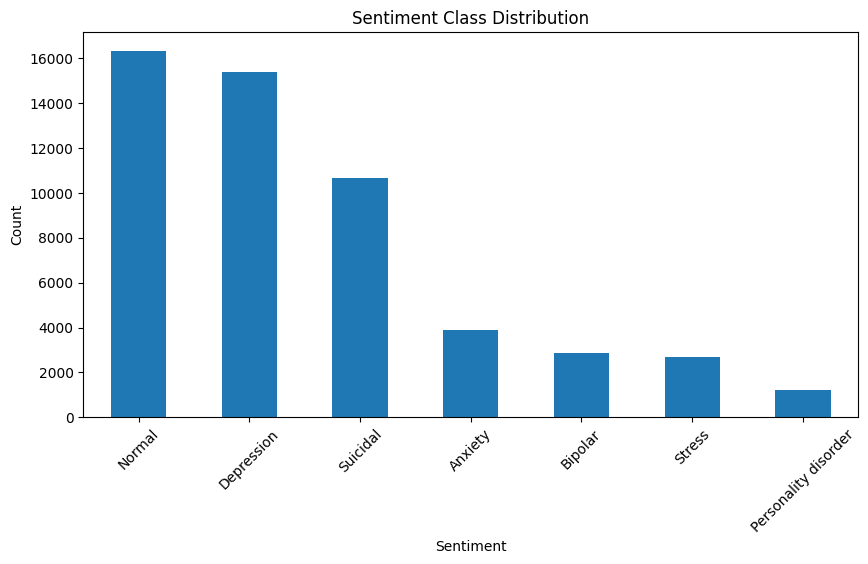


CLASS IMBALANCE ANALYSIS:

Maximum samples in class: 16351
Minimum samples in class: 1201
Imbalance Ratio: 13.614487926727726
Dataset is imbalanced

AVERAGE SENTENCE LENGTH:
112.39328469355051

ORIGINAL TEXT:

oh my gosh

CLEANED TEXT:

oh gosh

TOTAL WORDS IN VOCABULARY:
77703

FIRST 20 WORDS:

<OOV> : 1
like : 2
feel : 3
want : 4
know : 5
life : 6
get : 7
even : 8
time : 9
would : 10
people : 11
really : 12
cannot : 13
one : 14
going : 15
im : 16
think : 17
go : 18
much : 19
never : 20

SAMPLE TEXT:

oh gosh

SEQUENCE:

[488, 4592]

PADDED SEQUENCE SHAPE:
(53043, 50)

FIRST PADDED SEQUENCE:

[ 488 4592    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0]

WHY RNN CANNOT DIRECTLY UNDERSTAND RAW TEXT:



RNN models work only with numerical data.

Computers cannot understand words like:
'happy', 's

In [1]:
# ============================================
# AI-Based Mental Health Sentiment Monitoring
# Simple RNN Project
# ============================================

# Install if needed:
# pip install kagglehub pandas numpy matplotlib seaborn nltk scikit-learn tensorflow

# ============================================
# IMPORT LIBRARIES
# ============================================

import os
import re
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# ============================================
# DOWNLOAD DATASET USING KAGGLEHUB
# ============================================

import kagglehub

# Download latest version
path = kagglehub.dataset_download(
    "suchintikasarkar/sentiment-analysis-for-mental-health"
)

print("Path to dataset files:", path)

# ============================================
# LOAD DATASET
# ============================================

# Check files inside dataset folder
print(os.listdir(path))

# Usually dataset contains csv file
# Replace filename if needed
file_path = os.path.join(path, "Combined Data.csv")

df = pd.read_csv(file_path)

# ============================================
# DISPLAY DATASET
# ============================================

print("\nFIRST 5 ROWS:\n")
print(df.head())

print("\nDATASET SHAPE:")
print(df.shape)

print("\nCOLUMN NAMES:")
print(df.columns)

# ============================================
# TASK 1 — DATASET UNDERSTANDING
# ============================================

# --------------------------------------------
# 1. Number of Sentiment Classes
# --------------------------------------------

print("\nUNIQUE SENTIMENT CLASSES:\n")

print(df['status'].unique())

print("\nNUMBER OF CLASSES:")
print(df['status'].nunique())

# --------------------------------------------
# 2. Class Distribution
# --------------------------------------------

print("\nCLASS DISTRIBUTION:\n")

class_distribution = df['status'].value_counts()

print(class_distribution)

# --------------------------------------------
# VISUALIZE CLASS DISTRIBUTION
# --------------------------------------------

plt.figure(figsize=(10,5))

class_distribution.plot(kind='bar')

plt.title("Sentiment Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

# --------------------------------------------
# 3. Check Class Imbalance
# --------------------------------------------

print("\nCLASS IMBALANCE ANALYSIS:\n")

max_class = class_distribution.max()
min_class = class_distribution.min()

print("Maximum samples in class:", max_class)
print("Minimum samples in class:", min_class)

imbalance_ratio = max_class / min_class

print("Imbalance Ratio:", imbalance_ratio)

if imbalance_ratio > 2:
    print("Dataset is imbalanced")
else:
    print("Dataset is relatively balanced")

# --------------------------------------------
# 4. Average Sentence Length
# --------------------------------------------

df['sentence_length'] = df['statement'].apply(
    lambda x: len(str(x).split())
)

average_length = df['sentence_length'].mean()

print("\nAVERAGE SENTENCE LENGTH:")
print(average_length)

# ============================================
# TASK 2 — TEXT PREPROCESSING
# ============================================

# --------------------------------------------
# STOPWORDS
# --------------------------------------------

stop_words = set(stopwords.words('english'))

# --------------------------------------------
# CLEANING FUNCTION
# --------------------------------------------

def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove punctuation
    text = re.sub(f"[{re.escape(string.punctuation)}]", "", text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenization
    words = text.split()

    # Stopword removal
    words = [word for word in words if word not in stop_words]

    # Join words back
    text = " ".join(words)

    return text

# ============================================
# APPLY PREPROCESSING
# ============================================

df['clean_text'] = df['statement'].astype(str).apply(clean_text)

# ============================================
# DISPLAY CLEANED TEXT
# ============================================

print("\nORIGINAL TEXT:\n")
print(df['statement'].iloc[0])

print("\nCLEANED TEXT:\n")
print(df['clean_text'].iloc[0])

# ============================================
# TASK 3 — SEQUENCE PREPARATION
# ============================================

# --------------------------------------------
# VOCABULARY SIZE
# --------------------------------------------

VOCAB_SIZE = 5000

# --------------------------------------------
# TOKENIZER
# --------------------------------------------

tokenizer = Tokenizer(
    num_words=VOCAB_SIZE,
    oov_token="<OOV>"
)

# --------------------------------------------
# FIT TOKENIZER
# --------------------------------------------

tokenizer.fit_on_texts(df['clean_text'])

# ============================================
# WORD INDEXING
# ============================================

word_index = tokenizer.word_index

print("\nTOTAL WORDS IN VOCABULARY:")
print(len(word_index))

print("\nFIRST 20 WORDS:\n")

for word, index in list(word_index.items())[:20]:
    print(word, ":", index)

# ============================================
# TEXT TO SEQUENCES
# ============================================

sequences = tokenizer.texts_to_sequences(
    df['clean_text']
)

print("\nSAMPLE TEXT:\n")
print(df['clean_text'].iloc[0])

print("\nSEQUENCE:\n")
print(sequences[0])

# ============================================
# PADDING
# ============================================

MAX_LENGTH = 50

padded_sequences = pad_sequences(
    sequences,
    maxlen=MAX_LENGTH,
    padding='post',
    truncating='post'
)

print("\nPADDED SEQUENCE SHAPE:")
print(padded_sequences.shape)

print("\nFIRST PADDED SEQUENCE:\n")
print(padded_sequences[0])

# ============================================
# WHY RNN CANNOT UNDERSTAND RAW TEXT
# ============================================

print("\nWHY RNN CANNOT DIRECTLY UNDERSTAND RAW TEXT:\n")

explanation = """

RNN models work only with numerical data.

Computers cannot understand words like:
'happy', 'sad', 'depressed'

So text must be converted into numbers.

Steps:
1. Tokenization
   Convert words into tokens

2. Word Indexing
   Assign unique number to each word

3. Sequence Conversion
   Convert sentences into number sequences

4. Padding
   Make all sequences same length

Example:

'I feel sad'

becomes:

[12, 45, 98]

Only after numerical conversion can RNN process text sequentially.

"""

print(explanation)

# ============================================
# TRAIN TEST SPLIT
# ============================================

X = padded_sequences
y = df['status']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTRAIN SHAPE:", X_train.shape)
print("TEST SHAPE:", X_test.shape)


In [2]:
# ============================================
# TASK 4 — SIMPLE RNN MODEL
# CONTINUED FROM TASK 1-3
# ============================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

# Number of sentiment classes
num_classes = df['status'].nunique()

# ============================================
# LABEL ENCODING
# ============================================

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y = encoder.fit_transform(df['status'])

# ============================================
# TRAIN TEST SPLIT
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    padded_sequences,
    y,
    test_size=0.2,
    random_state=42
)

# ============================================
# BUILD MODEL
# ============================================

model = Sequential()

# Embedding Layer
model.add(
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=64,
        input_length=MAX_LENGTH
    )
)

# Simple RNN Layer
model.add(
    SimpleRNN(
        units=64,
        activation='tanh'
    )
)

# Output Layer
model.add(
    Dense(
        num_classes,
        activation='softmax'
    )
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [3]:
# ============================================
# TASK 5 — MODEL TRAINING
# ============================================

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# ============================================
# LEARNING RATE
# ============================================

learning_rate = 0.001

optimizer = Adam(
    learning_rate=learning_rate
)

# ============================================
# COMPILE MODEL
# ============================================

model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# ============================================
# EARLY STOPPING
# ============================================

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# ============================================
# TRAIN MODEL
# ============================================

history = model.fit(
    X_train,
    y_train,

    # Number of complete passes
    epochs=15,

    # Samples processed together
    batch_size=32,

    # 20% data for validation
    validation_split=0.2,

    callbacks=[early_stop],

    verbose=1
)

# ============================================
# EVALUATE MODEL
# ============================================

loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("\nTest Loss:", loss)
print("Test Accuracy:", accuracy)

Epoch 1/15
1061/1061 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.4815 - loss: 1.4260 - val_accuracy: 0.4624 - val_loss: 1.4844
Epoch 2/15
1061/1061 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.4745 - loss: 1.3983 - val_accuracy: 0.4905 - val_loss: 1.3250
Epoch 3/15
1061/1061 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.4822 - loss: 1.3849 - val_accuracy: 0.4439 - val_loss: 1.4565
Epoch 4/15
1061/1061 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.4795 - loss: 1.3909 - val_accuracy: 0.4697 - val_loss: 1.4081
Epoch 5/15
1061/1061 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.4970 - loss: 1.3656 - val_accuracy: 0.4540 - val_loss: 1.4366
332/332 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4961 - loss: 1.3099

Test Loss: 1.309882402420044
Test Accuracy: 0.4960882365703583


## Task 6 — Model Evaluation

332/332 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
Accuracy: 0.4960882269770949
Precision: 0.4234429040152314
Recall: 0.4960882269770949
F1 Score: 0.4045149212950642

CLASSIFICATION REPORT:

                      precision    recall  f1-score   support

             Anxiety       0.37      0.47      0.41       779
             Bipolar       0.21      0.07      0.10       580
          Depression       0.57      0.52      0.54      3100
              Normal       0.50      0.97      0.66      3327
Personality disorder       0.00      0.00      0.00       248
              Stress       0.00      0.00      0.00       557
            Suicidal       0.34      0.01      0.03      2018

            accuracy                           0.50     10609
           macro avg       0.28      0.29      0.25     10609
        weighted avg       0.42      0.50      0.40     10609


CONFUSION MATRIX:

[[ 363   31   58  327    0    0    0]
 [ 269   39   72  194    1    0    5]
 [  83   47 1600 1320    0    0   50]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

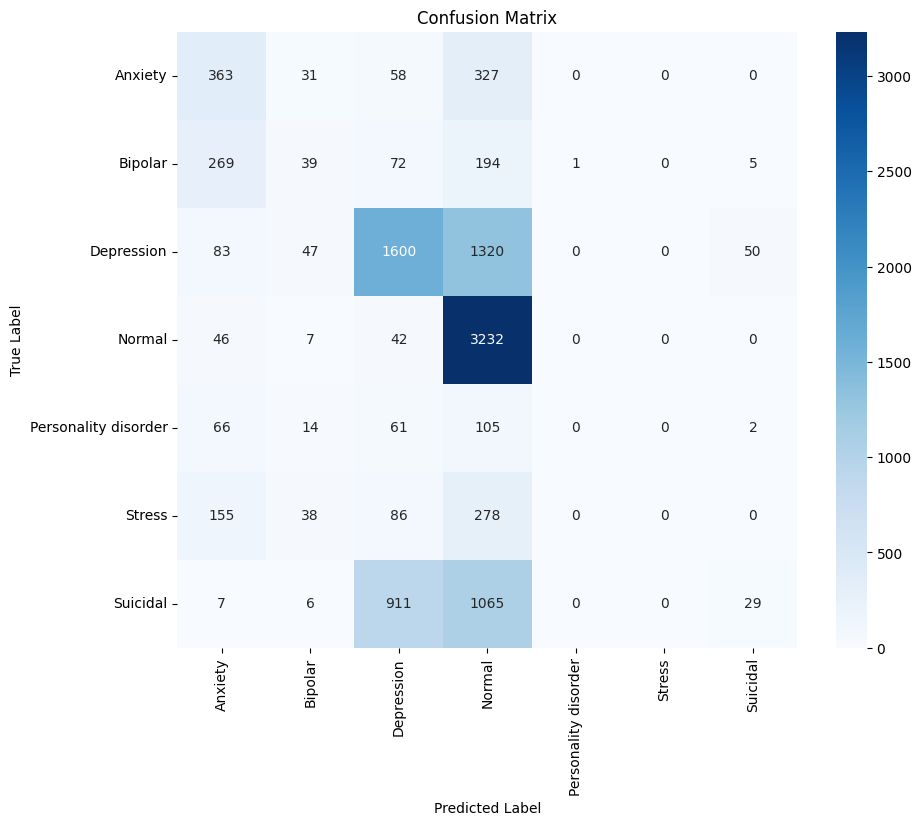

In [5]:
# ============================================
# TASK 6 — MODEL EVALUATION
# ============================================

from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report

import seaborn as sns
import matplotlib.pyplot as plt

# ============================================
# PREDICTIONS
# ============================================

y_pred_prob = model.predict(X_test)

# Convert probabilities into class labels
y_pred = y_pred_prob.argmax(axis=1)

# ============================================
# ACCURACY
# ============================================

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

# ============================================
# PRECISION
# ============================================

precision = precision_score(
    y_test,
    y_pred,
    average='weighted'
)

print("Precision:", precision)

# ============================================
# RECALL
# ============================================

recall = recall_score(
    y_test,
    y_pred,
    average='weighted'
)

print("Recall:", recall)

# ============================================
# F1 SCORE
# ============================================

f1 = f1_score(
    y_test,
    y_pred,
    average='weighted'
)

print("F1 Score:", f1)

# ============================================
# CLASSIFICATION REPORT
# ============================================

print("\nCLASSIFICATION REPORT:\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=encoder.classes_
    )
)

# ============================================
# CONFUSION MATRIX
# ============================================

cm = confusion_matrix(y_test, y_pred)

print("\nCONFUSION MATRIX:\n")
print(cm)

# ============================================
# VISUALIZE CONFUSION MATRIX
# ============================================

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.title("Confusion Matrix")

plt.show()

In [7]:
# ============================================
# TASK 7 — SEQUENCE UNDERSTANDING
# ============================================

print("""
RNN processes text sequentially, one word at a time.

Example sentence:
'I feel very sad today'

The RNN reads:
I → feel → very → sad → today

At every step, the RNN remembers information from previous words
using something called a Hidden State.

The hidden state acts like memory.

When processing the current word,
the RNN uses:
1. Current word information
2. Previous hidden state (memory)

This helps the model understand context and sequence.

For example:

'I am happy'
and
'I am not happy'

Both contain the word 'happy',
but previous words change the meaning.

RNN understands this using sequential learning behavior.

Sequential Learning:
- words are processed in order
- previous context influences future prediction
- hidden state keeps updating at every timestep

Flow:

Word1 + Previous Memory
            ↓
Updated Hidden State
            ↓
Next Word + Updated Memory
            ↓
Prediction
""")


RNN processes text sequentially, one word at a time.

Example sentence:
'I feel very sad today'

The RNN reads:
I → feel → very → sad → today

At every step, the RNN remembers information from previous words
using something called a Hidden State.

The hidden state acts like memory.

When processing the current word,
the RNN uses:
1. Current word information
2. Previous hidden state (memory)

This helps the model understand context and sequence.

For example:

'I am happy'
and
'I am not happy'

Both contain the word 'happy',
but previous words change the meaning.

RNN understands this using sequential learning behavior.

Sequential Learning:
- words are processed in order
- previous context influences future prediction
- hidden state keeps updating at every timestep

Flow:

Word1 + Previous Memory
            ↓
Updated Hidden State
            ↓
Next Word + Updated Memory
            ↓
Prediction



In [8]:
# ============================================
# TASK 8 — REAL-TIME PREDICTION
# ============================================

# Function for prediction

def predict_emotion(text):

    # Clean text
    cleaned_text = clean_text(text)

    # Convert text to sequence
    sequence = tokenizer.texts_to_sequences(
        [cleaned_text]
    )

    # Padding
    padded = pad_sequences(
        sequence,
        maxlen=MAX_LENGTH,
        padding='post'
    )

    # Predict
    prediction = model.predict(padded)

    # Highest probability class
    predicted_class = prediction.argmax(axis=1)

    # Convert label back
    sentiment = encoder.inverse_transform(
        predicted_class
    )

    # Confidence score
    confidence = prediction.max() * 100

    print("\nInput Sentence:", text)
    print("Predicted Emotion:", sentiment[0])
    print("Confidence Score:", round(confidence,2), "%")


# ============================================
# CUSTOM USER SENTENCES
# ============================================

predict_emotion(
    "I feel extremely happy today"
)

predict_emotion(
    "I feel lonely and depressed"
)

predict_emotion(
    "Nobody understands me anymore"
)

# ============================================
# EMOTIONAL TEXT EXAMPLES
# ============================================

predict_emotion(
    "I am stressed because of my exams"
)

predict_emotion(
    "Life feels beautiful and peaceful"
)

predict_emotion(
    "I cannot sleep and feel anxious"
)

# ============================================
# UNSEEN SENTENCES
# ============================================

predict_emotion(
    "Everything feels meaningless lately"
)

predict_emotion(
    "Today was one of the best days ever"
)

predict_emotion(
    "I am mentally exhausted and tired"
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 554ms/step

Input Sentence: I feel extremely happy today
Predicted Emotion: Normal
Confidence Score: 51.27 %
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step

Input Sentence: I feel lonely and depressed
Predicted Emotion: Normal
Confidence Score: 51.27 %
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step

Input Sentence: Nobody understands me anymore
Predicted Emotion: Normal
Confidence Score: 51.27 %
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step

Input Sentence: I am stressed because of my exams
Predicted Emotion: Normal
Confidence Score: 54.5 %
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step

Input Sentence: Life feels beautiful and peaceful
Predicted Emotion: Normal
Confidence Score: 51.27 %
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step

Input Sentence: I cannot sleep and feel anxious
Predicted Emotion: Normal
Confidence Score: 51.27 %
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step

Input Sentence: Everything feels meaningless lately
Predicted Emotion: Normal
Confidence Score: 51.27 %
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

In [9]:
# ============================================
# SAVE MODEL, TOKENIZER, LABEL ENCODER
# ============================================

import pickle

# Save trained RNN model
model.save("mental_health_rnn_model.h5")

print("Model saved successfully")

# ============================================
# SAVE TOKENIZER
# ============================================

with open("tokenizer.pkl", "wb") as file:
    pickle.dump(tokenizer, file)

print("Tokenizer saved successfully")

# ============================================
# SAVE LABEL ENCODER
# ============================================

with open("label_encoder.pkl", "wb") as file:
    pickle.dump(encoder, file)

print("Label encoder saved successfully")

Model saved successfully
Tokenizer saved successfully
Label encoder saved successfully
